In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    train_test_split_custom,
    calculate_sparse_fingerprints,
    build_fingerprint_vocabulary,
    build_fingerprint_index
)
def vectorize_sparse_fp(fp_dict: dict, fp_index: dict) -> np.ndarray:
    vector = np.zeros(len(fp_index), dtype=np.float32)
    for env_id, count in fp_dict.items():
        column = fp_index.get(env_id)
        if column is not None:
            vector[column] = count
    return vector


def vectorize_fingerprints(fp_dicts, fp_index) -> np.ndarray:
    return np.array([vectorize_sparse_fp(fp, fp_index) for fp in fp_dicts])


DB_PATH = "../../CCSMLDatabase.db"
TRAIN_CSV = "../../train_data.csv"
TEST_CSV = "../../test_data.csv"

# pure data split -- no model training -- matches train.py's own default args
train_test_split_custom(
    database_file=DB_PATH,
    test_size=0.2,
    random_state=26,
    use_metlin=True,
)

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Global style settings
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 3, # Thicker axis lines
    "axes.spines.top": True,          
    "axes.spines.right": True,          
    "xtick.major.width": 3, # Match tick thickness to axis
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "ytick.major.width": 3,
    "xtick.direction": "out", # Ticks point outside
    "ytick.direction": "out",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.labelweight": "normal",
})

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

56429 rows split by subclass
5110 rows split by class
20 rows split by superclass
4594 rows with no superclass/class/subclass -- added to training only
53351 train rows
12802 test rows
Train: 53351 rows | Test: 12802 rows


# Applicability domain via leverage (full non-hashed fingerprints)

Leverage `h = x^T (X_train^T X_train)^-1 x` measures how far a compound's fingerprint sits from the training set's descriptor space, accounting for correlation between fingerprint bits. Warning threshold `h* = 3p/n` (`p` = fingerprint columns, `n` = training molecules); compounds above it are outside the applicability domain -- the model is extrapolating for them. This is descriptor-space only (no model predictions needed), so it doesn't depend on having a trained regressor -- once one exists, standardized residuals can be added to turn this into a full Williams plot.

In [2]:
fp_min_count = 40

train_fps = calculate_sparse_fingerprints(train_df["smi"])
fp_vocab = build_fingerprint_vocabulary(train_fps, fp_min_count)
fp_index = build_fingerprint_index(fp_vocab)

test_fps = calculate_sparse_fingerprints(test_df["smi"])

X_train = vectorize_fingerprints(train_fps, fp_index).astype(np.float64)
X_test = vectorize_fingerprints(test_fps, fp_index).astype(np.float64)

p = X_train.shape[1]
n = X_train.shape[0]
print(f"Fingerprint vocabulary: {p} substructures kept (min_count={fp_min_count})")
print(f"Train: {n} molecules | Test: {len(X_test)} molecules")

Fingerprint vocabulary: 4709 substructures kept (min_count=40)
Train: 53351 molecules | Test: 12802 molecules


In [3]:
# pseudo-inverse, not a plain inverse -- fingerprint columns are collinear/sparse
# enough that X_train^T X_train is often singular or near-singular
XtX_pinv = np.linalg.pinv(X_train.T @ X_train)


def compute_leverage(X, XtX_pinv):
    return np.sum((X @ XtX_pinv) * X, axis=1)


train_leverage = compute_leverage(X_train, XtX_pinv)
test_leverage = compute_leverage(X_test, XtX_pinv)

warning_leverage = 3 * p / n

print(f"Warning leverage threshold h* = 3p/n = {warning_leverage:.4f}")
print(f"Train molecules above threshold: {(train_leverage > warning_leverage).sum()} / {n} "
      f"({(train_leverage > warning_leverage).mean() * 100:.1f}%)")
print(f"Test molecules above threshold (outside applicability domain): "
      f"{(test_leverage > warning_leverage).sum()} / {len(test_leverage)} "
      f"({(test_leverage > warning_leverage).mean() * 100:.1f}%)")

/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_67182/4137010015.py:3: RuntimeWarning: divide by zero encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_67182/4137010015.py:3: RuntimeWarning: overflow encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_67182/4137010015.py:3: RuntimeWarning: invalid value encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value enco

Warning leverage threshold h* = 3p/n = 0.2648
Train molecules above threshold: 920 / 53351 (1.7%)
Test molecules above threshold (outside applicability domain): 964 / 12802 (7.5%)


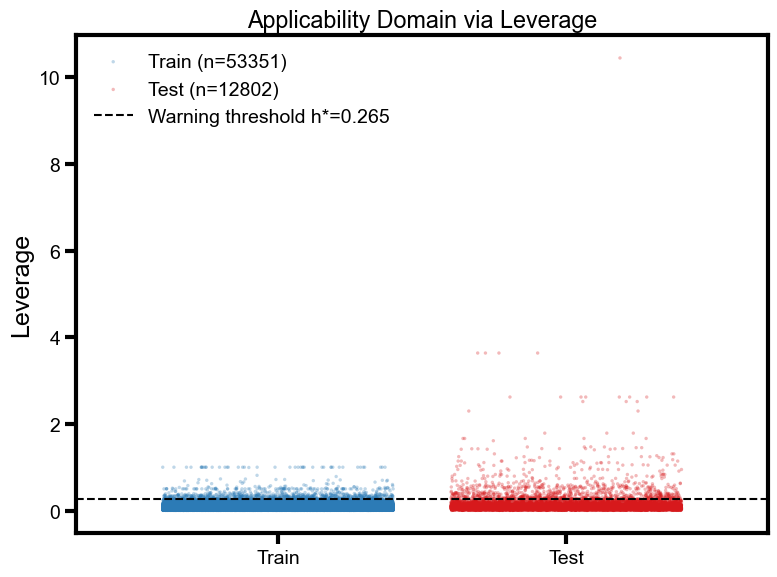

Warning threshold h* = 0.2648


In [5]:
rng = np.random.default_rng(26)
train_x = rng.uniform(-0.4, 0.4, size=len(train_leverage))
test_x = rng.uniform(0.6, 1.4, size=len(test_leverage))

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(train_x, train_leverage, s=6, alpha=0.3, color="#2c7bb6", edgecolors="none", label=f"Train (n={n})")
ax.scatter(test_x, test_leverage, s=6, alpha=0.3, color="#d7191c", edgecolors="none", label=f"Test (n={len(test_leverage)})")
ax.axhline(warning_leverage, color="black", linestyle="--", linewidth=1.5, label=f"Warning threshold h*={warning_leverage:.3f}")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Train", "Test"])
ax.set_xlim(-0.7, 1.7)
ax.set_ylabel("Leverage")
ax.set_title("Applicability Domain via Leverage")
ax.legend(frameon=False)

plt.tight_layout()
fig.savefig("applicability_domain_leverage.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Warning threshold h* = {warning_leverage:.4f}")